In [1]:
GPS_CRS = "EPSG:4326"
UTM_ZONE = "EPSG:32645"

In [2]:
PANOS_DIR = "data/street_view/panos"      # Source directory with raw {id}.jpg cylindrical panos
IMAGES_DIR = "data/street_view/images"    # Target directory for sliced perspective images
OUTPUT_JSON = "data/street_view/ground_truth.json"
VIEWPOINTS_PATH = "data/digital_elevation_model/viewpoints_mapping.npy"
MODEL_PATH = "data/sky_segmentation_unet_model.pth"
METADATA_CSV_PATH = "data/street_view/panos_metadata.csv"
MASKS_DIR = "data/street_view/masks"

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(METADATA_CSV_PATH)
df.shape

(2000, 27)

In [5]:
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': null_counts, 'Percentage (%)': null_percent})

missing_report[missing_report['Missing Count'] > 0]

,Missing Count,Percentage (%)
heading,14,0.70
pitch,14,0.70
roll,14,0.70
depth,2000,100.00
building_level,2000,100.00
upload_date,1784,89.20
elevation,184,9.20
country_code,566,28.30
street_names,2000,100.00
address,2000,100.00


In [6]:
fatal_mask = df['heading'].isnull() | df['lat'].isnull() | df['lon'].isnull()
fatal_rows = df[fatal_mask]

# Display the corrupted rows
fatal_rows[['id', 'lat', 'lon', 'heading']]

,id,lat,lon,heading
6,CIABIhDlwNr9o8METbzpu9hSGp8F,27.888281,86.637869,NaN
34,CIABIhAGbwPTJSBu2WfRC1kABYOH,27.835344,86.625114,NaN
60,CIHM0ogKEICAgIDq64zYLQ,27.880395,86.817162,NaN
85,CIABIhA0qCM1kFrFFgNvlfSauSiy,27.929410,86.623216,NaN
96,CIHM0ogKEICAgIDc472wlQE,27.822719,86.706505,NaN
154,CIABIhBr5ZkzR0kzQExHEvgIAqVV,27.923810,86.641889,NaN
198,CIHM0ogKEICAgID094-AhwE,27.926465,86.879057,NaN
235,CIABIhAQt43a4dyqLyz7UYmnvDuk,27.826266,86.697960,NaN
365,CIABIhCrIKtyS_LxVnjCLs_GZ_hl,27.834377,86.651666,NaN
371,CIHM0ogKEICAgIDe9sX6RA,27.932423,86.701389,NaN


In [7]:
missing_elevation = df[df['elevation'].isnull()]

# Display value counts of uploaders responsible for missing elevations
missing_elevation['uploader'].value_counts().to_frame()

,count
uploader,
Stephane Champoussin,43
MASATO,14
Grishkoff. PRO,12
Peng Shi,7
Philipp Hammes,5
...,...
Jackson Wales,1
Ryan Gray,1
Arla Dong,1


In [8]:
# Drop fatal rows and fill missing secondary tracking metrics with safe defaults
df = df.dropna(subset=["id", "lat", "lon", "heading", "pitch", "roll", "elevation"]).copy()
# Display final clean dimensions before image slicing
df.shape

(1816, 27)

In [9]:
df

,id,lat,lon,heading,pitch,roll,depth,tile_size,image_sizes,neighbors,...,country_code,street_names,address,places,artworks,source,copyright_message,uploader,uploader_icon_url,source_type
0,gtM1wHN3PY6ExdUpm_Kwxg,27.940744,86.701414,0.917307,0.071817,0.051263,NaN,"{""x"": 512, ""y"": 512}","[{""x"": 416, ""y"": 208}, {""x"": 832, ""y"": 416}, {...","[{""id"": ""KPJi059d0wnSUAfslI3OUQ"", ""lat"": null,...",...,NP,NaN,NaN,"[{""feature_id"": ""0x39e854a215bd9ebd:0x576dcf80...",[],scout,© 2026 Google,Google,//lh5.googleusercontent.com/-B45RREcFXCo/AAAAA...,scout
5,Z6KH-SzWSYFwORRaBGvNYg,27.982205,86.889017,4.944145,0.080525,6.265966,NaN,"{""x"": 512, ""y"": 512}","[{""x"": 416, ""y"": 208}, {""x"": 832, ""y"": 416}, {...",[],...,NaN,NaN,NaN,"[{""feature_id"": ""0x39e854a215bd9ebd:0x576dcf80...",[],scout,© 2026 Google,Google,//lh5.googleusercontent.com/-B45RREcFXCo/AAAAA...,scout
7,5LDxSllCwStxt7aJ35F2Ww,27.981219,86.688343,5.697645,0.104990,-0.037077,NaN,"{""x"": 512, ""y"": 512}","[{""x"": 416, ""y"": 208}, {""x"": 832, ""y"": 416}, {...","[{""id"": ""cV3QtcYUG0TMF2aHhXlyKw"", ""lat"": null,...",...,NP,NaN,NaN,"[{""feature_id"": ""0x39e854a215bd9ebd:0x576dcf80...",[],scout,© 2026 Google,Google,//lh5.googleusercontent.com/-B45RREcFXCo/AAAAA...,scout
9,EZ15hr7Ojg3ito6i3BY6YA,27.830584,86.663003,5.886147,0.077085,-0.047437,NaN,"{""x"": 512, ""y"": 512}","[{""x"": 416, ""y"": 208}, {""x"": 832, ""y"": 416}, {...","[{""id"": ""aVXxMlVQC9-zcxWW0rLJ8w"", ""lat"": null,...",...,NP,NaN,NaN,"[{""feature_id"": ""0x39e854a215bd9ebd:0x576dcf80...",[],scout,© 2026 Google,Google,//lh5.googleusercontent.com/-B45RREcFXCo/AAAAA...,scout
10,7MjMNO0rcwbYlY0p0BbpZQ,27.927785,86.799798,4.582743,0.100435,-0.064967,NaN,"{""x"": 512, ""y"": 512}","[{""x"": 416, ""y"": 208}, {""x"": 832, ""y"": 416}, {...","[{""id"": ""GZnluJvLnHxA6DUYVbTySQ"", ""lat"": null,...",...,NP,NaN,NaN,"[{""feature_id"": ""0x39e854a215bd9ebd:0x576dcf80...",[],scout,© 2026 Google,Google,//lh5.googleusercontent.com/-B45RREcFXCo/AAAAA...,scout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,otzoaeuaGYrahrZ8qzNrFg,27.900017,86.817571,2.835610,0.190796,0.080374,NaN,"{""x"": 512, ""y"": 512}","[{""x"": 416, ""y"": 208}, {""x"": 832, ""y"": 416}, {...","[{""id"": ""q8gcvpstgP8NXwy8U4PvEA"", ""lat"": null,...",...,NP,NaN,NaN,"[{""feature_id"": ""0x39e854a215bd9ebd:0x576dcf80...",[],scout,© 2026 Google,Google,//lh5.googleusercontent.com/-B45RREcFXCo/AAAAA...,scout
1996,1puCcfNdO9Xk4E7d1Zh-hg,27.899908,86.817653,2.332478,0.593799,0.063416,NaN,"{""x"": 512, ""y"": 512}","[{""x"": 416, ""y"": 208}, {""x"": 832, ""y"": 416}, {...","[{""id"": ""OjAu-9j0CvVxjOz7aB30dA"", ""lat"": null,...",...,NP,NaN,NaN,"[{""feature_id"": ""0x39e854a215bd9ebd:0x576dcf80...",[],scout,© 2026 Google,Google,//lh5.googleusercontent.com/-B45RREcFXCo/AAAAA...,scout
1997,83vUPBmYkrZLsygtVvv1QA,27.792342,86.715757,5.084425,0.035893,0.007407,NaN,"{""x"": 512, ""y"": 512}","[{""x"": 416, ""y"": 208}, {""x"": 832, ""y"": 416}, {...","[{""id"": ""lumIfrJdfRQ98v8ClJZmmg"", ""lat"": null,...",...,NP,NaN,NaN,"[{""feature_id"": ""0x39e854a215bd9ebd:0x576dcf80...",[],scout,© 2026 Google,Google,//lh5.googleusercontent.com/-B45RREcFXCo/AAAAA...,scout
1998,Xx-J1t1nptnqjIdJqM3fIg,27.792277,86.715738,2.617363,0.042781,6.279787,NaN,"{""x"": 512, ""y"": 512}","[{""x"": 416, ""y"": 208}, {""x"": 832, ""y"": 416}, {...","[{""id"": ""5j4Tq-TzoquC4MCbhnKlEA"", ""lat"": 27.79...",...,NaN,NaN,NaN,"[{""feature_id"": ""0x39e854a215bd9ebd:0x576dcf80...",[],scout,© 2026 Google,Google,//lh5.googleusercontent.com/-B45RREcFXCo/AAAAA...,scout


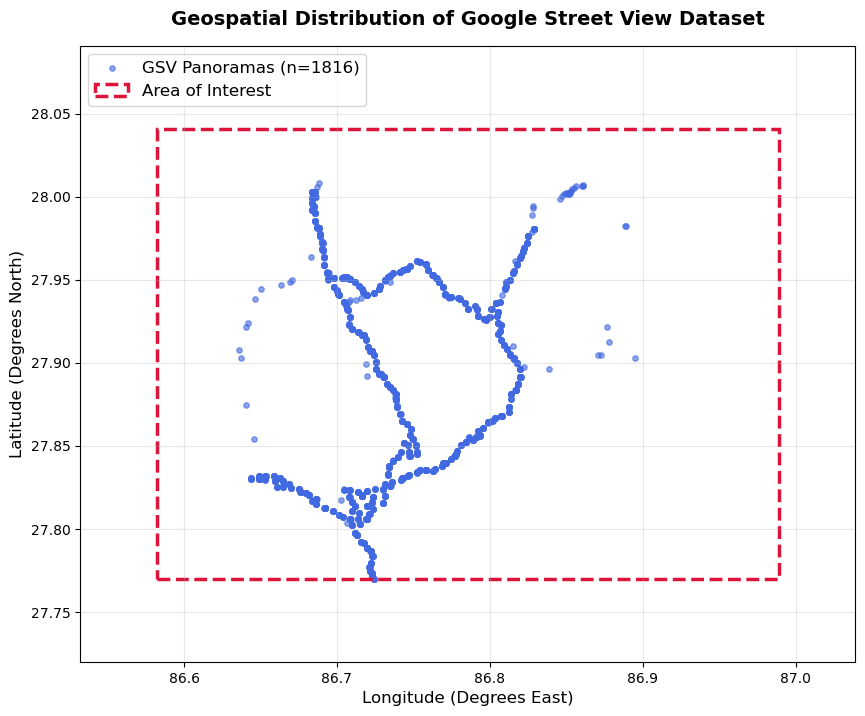

In [10]:
# GEOSPATIAL DISTRIBUTION PLOT CELL
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Canonical Khumbu Bounding Box coordinates
min_lon, max_lon = 86.582, 86.989
min_lat, max_lat = 27.770, 28.041

fig, ax = plt.subplots(figsize=(10, 8))

# 1. Scatter plot of the 2,000 clean GSV panorama coordinates
ax.scatter(
    df['lon'], 
    df['lat'], 
    color='royalblue', 
    alpha=0.6, 
    s=15, 
    label=f'GSV Panoramas (n={len(df)})'
)

# 2. Draw the bounding box rectangle
# Rectangle parameters: (lower-left corner, width, height)
rect_width = max_lon - min_lon
rect_height = max_lat - min_lat
rect = patches.Rectangle(
    (min_lon, min_lat), 
    rect_width, 
    rect_height, 
    linewidth=2.5, 
    edgecolor='crimson', 
    facecolor='none', 
    linestyle='--', 
    label='Area of Interest'
)
ax.add_patch(rect)

# 3. Aesthetics
ax.set_title("Geospatial Distribution of Google Street View Dataset", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Longitude (Degrees East)", fontsize=12)
ax.set_ylabel("Latitude (Degrees North)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='upper left')

# Set map limits slightly wider than the bounding box for padding
padding = 0.05
ax.set_xlim(min_lon - padding, max_lon + padding)
ax.set_ylim(min_lat - padding, max_lat + padding)

# Display the interactive plot inside the notebook
plt.show()

In [11]:
import os
import numpy as np
from PIL import Image

In [12]:
# --- SCAN AND REMOVE CORRUPTED PHYSICAL FILES FROM df ---
corrupted_ids = []
print(f"Scanning 'panos/' folder for corrupted files...")
for file in os.listdir(PANOS_DIR):
    if not file.endswith((".jpg", ".jpeg", ".png")):
        continue
    path = os.path.join(PANOS_DIR, file)
    try:
        with Image.open(path) as img:
            img.verify()  # Fast structural verification
    except Exception:
        # Get the unique GSV ID from the filename (e.g., "SHP28HYAjxwXZs1aT_4jhw")
        pano_id = os.path.splitext(file)[0]
        corrupted_ids.append(pano_id)

print(f"  Found {len(corrupted_ids)} corrupted physical files.")

# Filter df to exclude these corrupted panorama IDs
initial_count = len(df)
df = df[~df['id'].astype(str).isin(corrupted_ids)]
dropped_count = initial_count - len(df)

print(f"✓ Dropped {dropped_count} corrupted entries from df.")
print(f"✓ Dataset ready. Slicing {len(df)} clean, verified GSV panoramas...")

Scanning 'panos/' folder for corrupted files...
  Found 1 corrupted physical files.
✓ Dropped 1 corrupted entries from df.
✓ Dataset ready. Slicing 1815 clean, verified GSV panoramas...


In [13]:
import os
import numpy as np

In [14]:
os.makedirs(IMAGES_DIR, exist_ok=True)

In [15]:
def vertical_to_horizontal_fov(vertical_fov_deg, aspect_ratio=1.5):
    return np.degrees(2.0 * np.arctan(np.tan(np.radians(vertical_fov_deg) / 2.0) * aspect_ratio))

def slice_perspective(pano_path, heading_deg, pitch_deg, roll_deg, fov_y_deg=65.0, out_w=1080, out_h=720):
    """
    Extracts a perspective image from a cylindrical equirectangular panorama.
    """
    pano_img = Image.open(pano_path).convert("RGB")
    pano_w, pano_h = pano_img.size
    pano_arr = np.array(pano_img)
    
    aspect_ratio = out_w / out_h
    focal_y = out_h / (2.0 * np.tan(np.radians(fov_y_deg) / 2.0))
    focal_x = out_w / (2.0 * np.tan(np.radians(vertical_to_horizontal_fov(fov_y_deg, aspect_ratio)) / 2.0))
    
    u, v = np.meshgrid(np.arange(out_w), np.arange(out_h))
    x_cam = (u - out_w / 2.0) / focal_x
    y_cam = (out_h / 2.0 - v) / focal_y
    z_cam = -np.ones_like(x_cam)
    
    rays_cam = np.stack((x_cam, y_cam, z_cam), axis=-1)
    norms = np.linalg.norm(rays_cam, axis=-1, keepdims=True)
    rays_cam_norm = rays_cam / norms
    
    h = np.radians(heading_deg)
    p = np.radians(pitch_deg)
    r = np.radians(roll_deg)
    
    # yaw (heading) clockwise rotation
    R_yaw = np.array([
        [np.cos(h), np.sin(h), 0],
        [-np.sin(h), np.cos(h), 0],
        [0, 0, 1]
    ])
    R_pitch = np.array([
        [1, 0, 0],
        [0, np.cos(p), -np.sin(p)],
        [0, np.sin(p), np.cos(p)]
    ])
    R_roll = np.array([
        [np.cos(r), -np.sin(r), 0],
        [np.sin(r), np.cos(r), 0],
        [0, 0, 1]
    ])
    
    # Camera sensor-to-world axis alignment matrix:
    # Maps camera Right (+X) to world East (+X), Up (+Y) to world Up (+Z), and Forward (-Z) to world North (+Y)
    R_sensor_to_world = np.array([
        [1,  0,  0],
        [0,  0, -1],
        [0,  1,  0]
    ])
    
    # Combined rotation camera-to-world with axis alignment
    R_world = R_yaw @ R_pitch @ R_roll @ R_sensor_to_world
    
    flat_rays = rays_cam_norm.reshape(-1, 3)
    rotated_rays = (R_world @ flat_rays.T).T
    
    theta = np.arctan2(rotated_rays[:, 0], rotated_rays[:, 1])
    phi = np.arcsin(np.clip(rotated_rays[:, 2], -1.0, 1.0))
    
    x_pano = (theta + np.pi) / (2.0 * np.pi) * (pano_w - 1)
    y_pano = (np.pi / 2.0 - phi) / np.pi * (pano_h - 1)
    
    x_pano = x_pano.reshape(out_h, out_w)
    y_pano = y_pano.reshape(out_h, out_w)
    
    x0 = np.floor(x_pano).astype(np.int32)
    x1 = np.clip(x0 + 1, 0, pano_w - 1)
    y0 = np.floor(y_pano).astype(np.int32)
    y1 = np.clip(y0 + 1, 0, pano_h - 1)
    
    wa = (x1 - x_pano) * (y1 - y_pano)
    wb = (x_pano - x0) * (y1 - y_pano)
    wc = (x1 - x_pano) * (y_pano - y0)
    wd = (x_pano - x0) * (y_pano - y0)
    
    out_arr = np.zeros((out_h, out_w, 3), dtype=np.uint8)
    for c in range(3):
        out_arr[:, :, c] = (
            wa * pano_arr[y0, x0, c] +
            wb * pano_arr[y0, x1, c] +
            wc * pano_arr[y1, x0, c] +
            wd * pano_arr[y1, x1, c]
        ).astype(np.uint8)
        
    return Image.fromarray(out_arr)

def build_tilt_matrix(pitch_rad, roll_rad):
    R_x = np.array([
        [1, 0, 0],
        [0, np.cos(pitch_rad), -np.sin(pitch_rad)],
        [0, np.sin(pitch_rad), np.cos(pitch_rad)]
    ], dtype=np.float32)
    R_z = np.array([
        [np.cos(roll_rad), -np.sin(roll_rad), 0],
        [np.sin(roll_rad), np.cos(roll_rad), 0],
        [0, 0, 1]
    ], dtype=np.float32)
    return (R_x @ R_z).tolist()

In [16]:
import json
from pyproj import Transformer
from tqdm import tqdm

In [17]:
# Setup reference viewpoints database and coordinate projection mapper
viewpoints_mapping = np.load(VIEWPOINTS_PATH)
gps_to_utm = Transformer.from_crs(GPS_CRS, UTM_ZONE, always_xy=True)

metadata_dict = {}
success_count = 0

print(f"Dataset ready. Slicing {len(df)} clean GSV panoramas...")

Dataset ready. Slicing 1815 clean GSV panoramas...


In [18]:
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
    pano_id = str(row["id"])
    pano_file = os.path.join(PANOS_DIR, f"{pano_id}.jpg")
    target_img_file = os.path.join(IMAGES_DIR, f"{pano_id}.png")
    
    # Skip if panorama file is missing
    if not os.path.exists(pano_file):
        continue
        
    lat = float(row["lat"])
    lon = float(row["lon"])
    elevation = float(row["elevation"])
    
    # Raw angles are in radians
    heading_rad = float(row["heading"])
    pitch_rad = float(row["pitch"])
    roll_rad = float(row["roll"])
    
    # Convert angles
    heading_deg = np.degrees(heading_rad) % 360.0
    pitch_deg = np.degrees(pitch_rad)
    roll_deg = np.degrees(roll_rad)
    
    # 1. Slice panorama into standard perspective image with Gorge Avoidance
    try:
        # Initial slice at default heading
        sliced_img = slice_perspective(
            pano_file, 
            heading_deg=heading_deg, 
            pitch_deg=pitch_deg, 
            roll_deg=roll_deg, 
            fov_y_deg=65.0
        )
        
        # Analyze brightness of the top 15% of the sliced image (the sky region)
        # Sliced height is 720, so top 15% is rows 0 to 108
        temp_arr = np.array(sliced_img)
        avg_top_brightness = np.mean(temp_arr[:108, :, :])
        
        # If the sky is blocked by dark dirt/trail texture (mean brightness < 85)
        if avg_top_brightness < 85.0:
            # Try looking in the opposite direction (180 degree yaw rotation)
            opposite_heading = (heading_deg + 180.0) % 360.0
            sliced_img_alt = slice_perspective(
                pano_file, 
                heading_deg=opposite_heading, 
                pitch_deg=pitch_deg, 
                roll_deg=roll_deg, 
                fov_y_deg=65.0
            )
            
            temp_arr_alt = np.array(sliced_img_alt)
            avg_top_brightness_alt = np.mean(temp_arr_alt[:108, :, :])
            
            if avg_top_brightness_alt > avg_top_brightness:
                # The opposite view has a significantly brighter (and therefore open sky) horizon!
                sliced_img = sliced_img_alt
                heading_deg = opposite_heading
                avg_top_brightness = avg_top_brightness_alt
                
        # Final safety check: if even after 180 rotation the skyline region is still completely dark,
        # it is a severe narrow canyon or heavily obstructed view on both sides. Skip it.
        if avg_top_brightness < 75.0:
            continue
            
        sliced_img.save(target_img_file)
    except Exception as e:
        print(f"Error slicing pano {pano_id}: {e}")
        continue
        
    # 2. Convert coordinates and map closest reference ID
    eye_x_utm, eye_y_utm = gps_to_utm.transform(lon, lat)
    dists = np.sum((viewpoints_mapping[:, 2:4] - np.array([eye_x_utm, eye_y_utm]))**2, axis=1)
    closest_idx = int(np.argmin(dists))
    closest_dist = float(np.sqrt(dists[closest_idx]))
    
    # Ground truth schema (Uses unique Pano string ID as the key)
    metadata_dict[pano_id] = {
        "true_lat": lat,
        "true_lon": lon,
        "eye_x_utm": eye_x_utm,
        "eye_y_utm": eye_y_utm,
        "eye_z_m": elevation + QUERY_MIN_HEIGHT_M if 'QUERY_MIN_HEIGHT_M' in globals() else elevation + 1.8,
        "closest_viewpoint_id": closest_idx,
        "closest_viewpoint_dist_m": closest_dist,
        "fov_y_deg": 65.0,
        "true_heading_deg": heading_deg,
        "cam_R_tilt": build_tilt_matrix(pitch_rad, roll_rad)
    }
    success_count += 1

# Save output JSON
with open(OUTPUT_JSON, 'w') as f:
    json.dump(metadata_dict, f, indent=4)

print(f"\n✓ Dataset preparation complete!")
print(f"  Successfully sliced and formatted {success_count}/{len(df)} images.")

Processing: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1815/1815 [07:10<00:00,  4.22it/s]


✓ Dataset preparation complete!
  Successfully sliced and formatted 1808/1815 images.


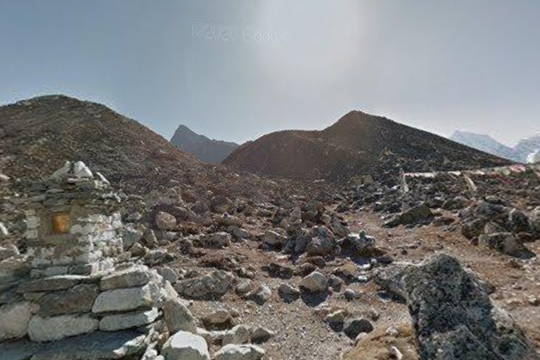

Visualized perspective slice for panorama ID: 2VlKKP-waMXSSviSuAIINQ


In [19]:
# Fast visual verification of sliced output
import random
valid_keys = list(metadata_dict.keys())
if len(valid_keys) > 0:
    random_key = random.choice(valid_keys)
    sliced_path = os.path.join(IMAGES_DIR, f"{random_key}.png")
    display(Image.open(sliced_path).resize((540, 360)))
    print(f"Visualized perspective slice for panorama ID: {random_key}")
else:
    print("No sliced panoramas available to display.")